In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/NLP_PHASE_2/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_happy', 'OAF_Fear', 'OAF_angry', 'OAF_disgust', 'OAF_neutral']


In [3]:
!pip install tensorflow librosa scikit-learn seaborn

In [4]:

# IMPORT LIBRARIES

import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    Concatenate
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.utils import to_categorical

In [5]:

# LOAD MULTIMODAL DATA


speech_features = []
texts = []
labels = []

print("Loading multimodal dataset...")

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            try:

                file_path = os.path.join(root, file)

                filename = file.replace(".wav", "")

                parts = filename.split("_")

                word = parts[1].lower().strip()

                emotion = parts[-1].lower().strip()

                emotion = emotion.split(" ")[0]

                # LOAD AUDIO

                audio, sr = librosa.load(
                    file_path,
                    sr=22050
                )

                # MFCC FEATURE EXTRACTION


                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                mfcc = np.mean(mfcc.T, axis=0)


                speech_features.append(mfcc)

                texts.append(word)

                labels.append(emotion)

            except Exception as e:

                print("Error:", file)
                print(e)

print("\nMultimodal dataset loaded successfully.")

print("\nSpeech Feature Shape:")
print(np.array(speech_features).shape)

print("\nSample Texts:")
print(texts[:10])

print("\nEmotion Classes:")
print(sorted(set(labels)))

Loading multimodal dataset...

Multimodal dataset loaded successfully.

Speech Feature Shape:
(2803, 40)

Sample Texts:
['calm', 'bought', 'doll', 'bite', 'date', 'came', 'bone', 'beg', 'book', 'dog']

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']


In [6]:

# TOKENIZATION


tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

text_sequences = tokenizer.texts_to_sequences(texts)

text_features = pad_sequences(
    text_sequences,
    padding='post'
)

print("Text Feature Shape:")
print(text_features.shape)

Text Feature Shape:
(2803, 1)


In [7]:

# LABEL ENCODING


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(labels)

y = to_categorical(y_encoded)

print("Emotion Classes:")
print(encoder.classes_)

Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [8]:

# TRAIN TEST SPLIT


X_speech_train, X_speech_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(

    np.array(speech_features),
    text_features,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Speech Train Shape:", X_speech_train.shape)

print("Text Train Shape:", X_text_train.shape)

Speech Train Shape: (2242, 40)
Text Train Shape: (2242, 1)


In [9]:

# BUILD MULTIMODAL FUSION MODEL


speech_input = Input(shape=(40,))

speech_branch = Dense(
    128,
    activation='relu'
)(speech_input)

speech_branch = Dropout(0.3)(speech_branch)

text_input = Input(shape=(X_text_train.shape[1],))

vocab_size = len(tokenizer.word_index) + 1

text_branch = Embedding(
    input_dim=vocab_size,
    output_dim=32
)(text_input)

text_branch = Flatten()(text_branch)

text_branch = Dense(
    64,
    activation='relu'
)(text_branch)

fusion = Concatenate()([
    speech_branch,
    text_branch
])


fusion = Dense(
    128,
    activation='relu'
)(fusion)

fusion = Dropout(0.3)(fusion)

output = Dense(
    y.shape[1],
    activation='softmax'
)(fusion)


model = Model(
    inputs=[speech_input, text_input],
    outputs=output
)


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │      6,432 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      5,248 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,112 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │        903 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,399 (153.90 KB)

 Trainable params: 39,399 (153.90 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:

# TRAIN FUSION MODEL


history = model.fit(

    [X_speech_train, X_text_train],
    y_train,

    epochs=20,
    batch_size=32,

    validation_data=(
        [X_speech_test, X_text_test],
        y_test
    )
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.2190 - loss: 21.0017 - val_accuracy: 0.5294 - val_loss: 1.2578
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3296 - loss: 4.0586 - val_accuracy: 0.4278 - val_loss: 1.6368
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3898 - loss: 1.9863 - val_accuracy: 0.4064 - val_loss: 1.6537
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4282 - loss: 1.6506 - val_accuracy: 0.6453 - val_loss: 1.3138
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4884 - loss: 1.3492 - val_accuracy: 0.7184 - val_loss: 1.0331
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5504 - loss: 1.1947 - val_accuracy: 0.8128 - val_loss: 0.8094
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6191 - loss: 1.0085 - val_accuracy: 0.8200 - val_loss: 0.6856
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6918 - loss: 0.8338 - val_accuracy: 0.9198 - val_los

In [11]:

# MODEL EVALUATION


loss, accuracy = model.evaluate(
    [X_speech_test, X_text_test],
    y_test
)

print("\nFusion Model Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9840 - loss: 0.0684 

Fusion Model Accuracy: 0.9839572310447693


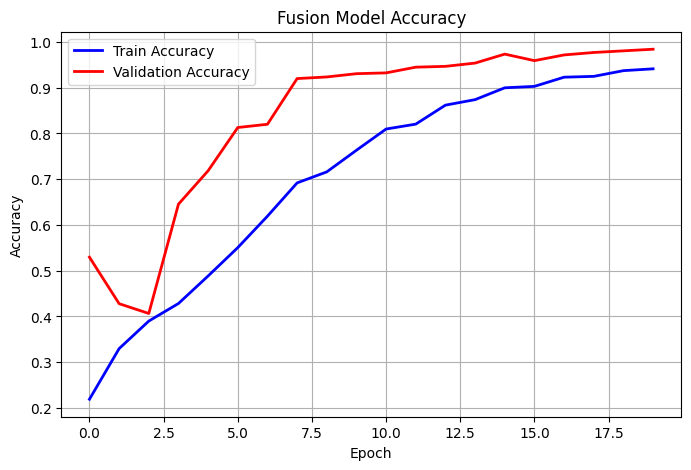

In [12]:

# ACCURACY PLOT


plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    color='blue',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    color='red',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Fusion Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


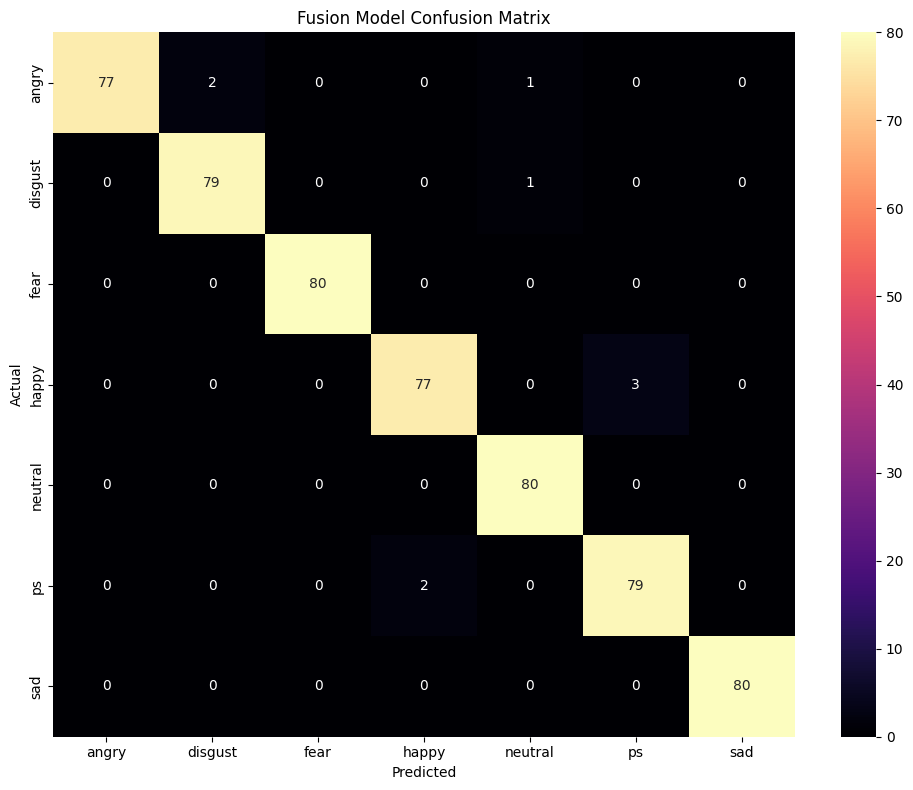

In [13]:

# CONFUSION MATRIX


y_pred = model.predict(
    [X_speech_test, X_text_test]
)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fusion Model Confusion Matrix")

plt.tight_layout()

plt.show()

In [14]:

# CLASSIFICATION REPORT


print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry       1.00      0.96      0.98        80
     disgust       0.98      0.99      0.98        80
        fear       1.00      1.00      1.00        80
       happy       0.97      0.96      0.97        80
     neutral       0.98      1.00      0.99        80
          ps       0.96      0.98      0.97        81
         sad       1.00      1.00      1.00        80

    accuracy                           0.98       561
   macro avg       0.98      0.98      0.98       561
weighted avg       0.98      0.98      0.98       561



18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


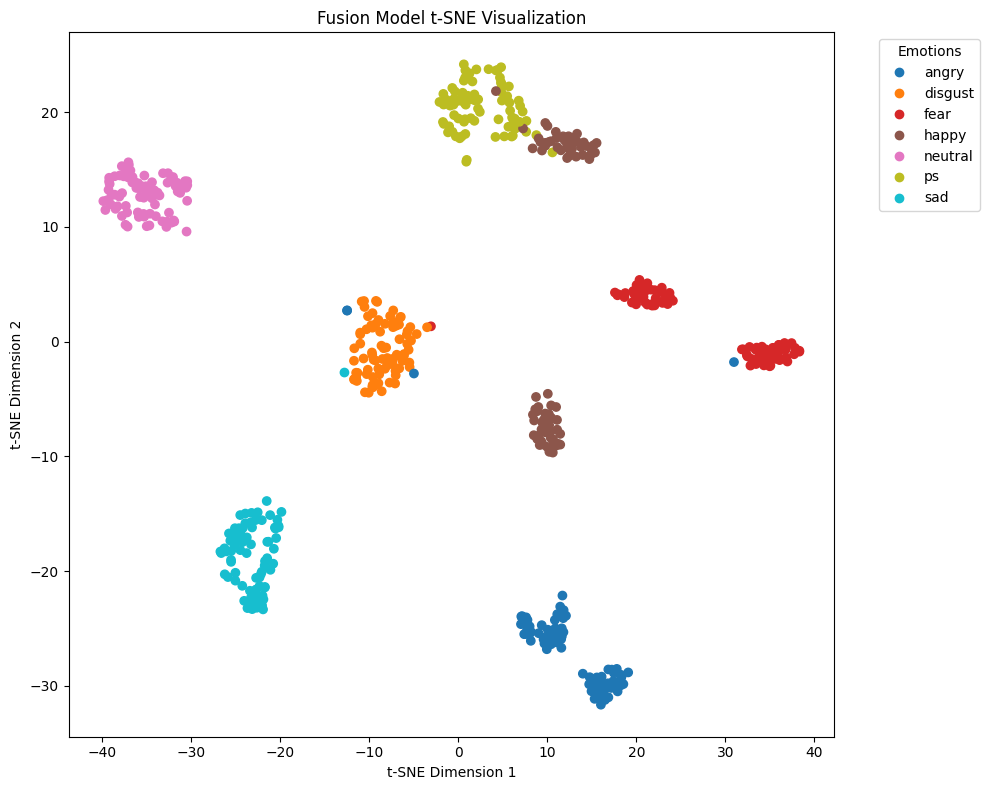

In [15]:

# FUSION MODEL t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

fusion_features = feature_extractor.predict(
    [X_speech_test, X_text_test]
)

tsne = TSNE(
    n_components=2,
    random_state=42
)

tsne_result = tsne.fit_transform(fusion_features)

y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=y_true,
    cmap='tab10'
)


handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    encoder.classes_,
    title="Emotions",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Fusion Model t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.tight_layout()

plt.show()

In [19]:

# SAVE MODEL


model.save(
    "/content/drive/MyDrive/NLP_PHASE_2/fusion.keras"
)

print("Fusion model saved successfully.")

Fusion model saved successfully.
